[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chreissel/sbi-tutorial-iaifi26/blob/main/01_sbi_foundations_student.ipynb)

# Notebook 1 — SBI from scratch: from regression to a calibrated posterior

**IAIFI Summer School · simulation-based inference · Session 1 (~60 min).**

In this tutorial, we try to answer the question: given a simulator and one observation, what is the posterior `p(θ|x)` — and can we trust its width?

The arc: a Gaussian regression head *is* already a (crude) posterior → why
that loss recovers the posterior at all → where the Gaussian shape breaks →
expressive density estimators (mixture head, flow matching) that don't →
whether the result is *calibrated* → and finally amortised vs sequential
inference under a fixed simulation budget.

> ### ▶️ Run this cell first

In [1]:
!git clone -q https://github.com/chreissel/sbi-tutorial-iaifi26.git
%cd sbi-tutorial-iaifi26
!pip install -q -r requirements.txt
!pip install -q --no-deps git+https://github.com/cweniger/teaching-2606-ICTP-SAIFR.git

fatal: destination path 'sbi-tutorial-iaifi26' already exists and is not an empty directory.
/content/sbi-tutorial-iaifi26
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm.auto import trange

from samma_sbi.simulators import BallThrow

SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
dev = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {dev}' + ('' if dev == 'cuda' else '  (a T4 GPU is nicer, but CPU is fine here)'))

device: cpu  (a T4 GPU is nicer, but CPU is fine here)


---
## 0 — Framing (read, no code)

**The problem.** We have a *simulator* `x ~ p(x|θ)`: give it parameters `θ`,
it returns synthetic data `x`. We have one real observation `x_obs`. We want
the posterior `p(θ|x_obs) ∝ p(x_obs|θ) p(θ)`. The obstacle is that for any
interesting simulator the **likelihood `p(x|θ)` is intractable** — it is an
integral over every random number the simulator drew internally. So classical
likelihood-based inference (write down `p(x|θ)`, run MCMC) is off the table.

**Simulation-based inference (SBI)** replaces the likelihood with the
simulator itself: draw pairs `(θ, x)`, and train a neural network on them.
Three flavours differ in *what* the network learns:

| | learns | inference |
|---|---|---|
| **NPE** (posterior) | `q_φ(θ\|x) ≈ p(θ\|x)` directly | one forward pass / sample |
| **NLE** (likelihood) | `q_φ(x\|θ) ≈ p(x\|θ)` | still needs MCMC on top |
| **NRE** (ratio) | `r_φ(x,θ) ≈ p(x\|θ)/p(x)` | still needs MCMC on top |

**NPE dominates in practice** for one reason: it targets the object you
actually want (the posterior), and sampling it is trivial — no MCMC, no
per-observation optimisation. NLE/NRE are worth it mainly when the likelihood
or ratio is the natural quantity, or when you want to reuse a likelihood
across priors. This whole notebook is NPE.

**Amortised vs sequential.** An *amortised* NPE is trained on `θ ~ p(θ)` from
the full prior, so `q_φ(θ|x)` works for **any** `x` in one shot — expensive to
train, free to reuse. A *sequential* NPE spends its simulation budget only
near one `x_obs`, retraining as it zooms in — cheaper for a single target,
but not reusable. §6 pits them against each other. Everything until then is
amortised.

---
## 1 — The whole game in ~20 lines (a reference cell, not an exercise)

Here is a complete, working amortised NPE. The simulator is the
ball-throw example: launch a projectile at angle `θ`, measure where it lands. The
range is `r(θ) = (v²/g) sin(2θ)`, observed as the mean of `n_balls` noisy
landings. We restrict the prior to `(0.05, π/4)` so the map `θ → r` is
one-to-one for now (no ambiguity yet — that comes in §3).

The posterior model is a **heteroscedastic Gaussian head**: an MLP that
outputs *both* a mean `μ_θ(x)` and a log-variance `log σ²_θ(x)`, so the width
depends on `x`. We train it by the Gaussian negative log-likelihood and
overlay the result on the *exact* analytic posterior at three values of `θ`.
Read it, run it, move on.

train: torch.Size([4000, 1])   val: torch.Size([400, 1])


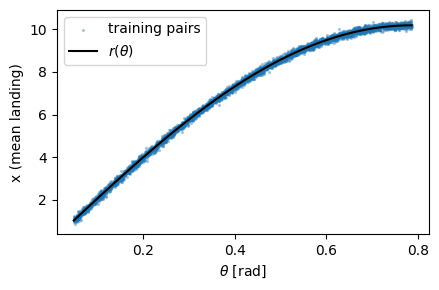

In [3]:
# training dataset
N_BALLS = 10
sim = BallThrow(prior_low=0.05, prior_high=np.pi / 4) # one-to-one range map
rng = np.random.default_rng(SEED)

def simulate_dataset(sim, n_pairs, n_balls, rng):
    theta = sim.sample_prior(n_pairs, rng=rng)
    x = sim.simulate_summary(theta, n_balls=n_balls, rng=rng)
    theta_t = torch.tensor(theta, dtype=torch.float32).unsqueeze(1)  # (N, 1)
    x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1)          # (N, 1)
    return theta_t, x_t

N_TRAIN, N_VAL = 4000, 400
rng = np.random.default_rng(SEED)
theta_tr, x_tr = simulate_dataset(sim, N_TRAIN, N_BALLS, rng)
theta_va, x_va = simulate_dataset(sim, N_VAL, N_BALLS, rng)
print("train:", theta_tr.shape, "  val:", theta_va.shape)

theta_grid = np.linspace(sim.prior_low, sim.prior_high, 1001)
plt.figure(figsize=(4.5, 3))
plt.scatter(theta_tr.numpy(), x_tr.numpy(), s=2, alpha=0.3, label="training pairs")
plt.plot(theta_grid, sim.range_mean(theta_grid), "k-", lw=1.5, label=r"$r(\theta)$")
plt.xlabel(r"$\theta$ [rad]"); plt.ylabel("x (mean landing)"); plt.legend()
plt.tight_layout(); plt.show()

In [4]:
def gaussian_nll(theta, mu, log_var):
    """1-D Gaussian NLL, averaged over the batch."""
    return 0.5 * (((theta - mu) ** 2) / torch.exp(log_var) + log_var).mean()


class GaussianBand1D(nn.Module):
    """Gaussian band whose width depends on x: mu_θ(x) AND log σ²_θ(x)."""

    def __init__(self, hidden=64):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head_mu = nn.Linear(hidden, 1)
        self.head_logvar = nn.Linear(hidden, 1)   # <-- width is an OUTPUT

    def forward(self, x):
        h = self.trunk(x)
        return self.head_mu(h), self.head_logvar(h)


# normalize inputs, so the network sees O(1) numbers
# not strictly necessary but makes the plots look nicer since training converges faster
theta_mu, theta_sd = theta_tr.mean(0), theta_tr.std(0)
x_mu, x_sd = x_tr.mean(0), x_tr.std(0)
theta_trn = (theta_tr - theta_mu) / theta_sd
x_trn = (x_tr - x_mu) / x_sd

model = GaussianBand1D()
opt = optim.Adam(model.parameters(), lr=1e-3)
bar = trange(300, desc="train Gaussian head", leave=False)
for _ in bar:
    perm = torch.randperm(x_trn.shape[0])
    for i in range(0, x_trn.shape[0], 256):
        idx = perm[i:i + 256]
        opt.zero_grad()
        loss = gaussian_nll(theta_trn[idx], *model(x_trn[idx]))   # train in normalized units
        loss.backward(); opt.step()
    bar.set_postfix(loss=f"{loss.item():.3f}")

train Gaussian head:   0%|          | 0/300 [00:00<?, ?it/s]

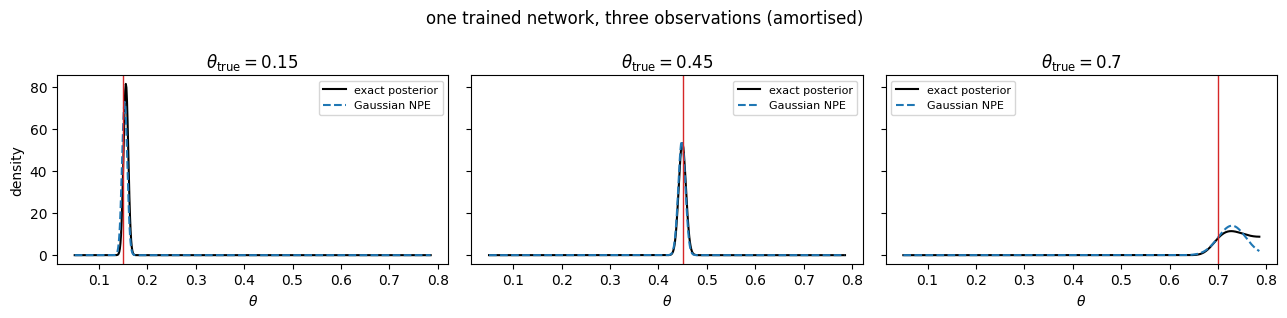

In [5]:
theta_grid = np.linspace(sim.prior_low, sim.prior_high, 600)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, theta_true in zip(axes, [0.15, 0.45, 0.70]):
    x_obs = float(sim.simulate_summary(np.array([theta_true]), n_balls=N_BALLS,
                                       rng=np.random.default_rng(int(1000 * theta_true)))[0])
    # normalize the observation
    x_obs_n = (torch.tensor([[x_obs]], dtype=torch.float32) - x_mu) / x_sd
    with torch.no_grad():
        mu_n, lv_n = model(x_obs_n)
    # map back to (un)normalized units
    mu = (mu_n * theta_sd + theta_mu).item()            # de-normalize the mean
    sg = (torch.exp(0.5 * lv_n) * theta_sd).item()      # sigma scales by theta_sd
    q = (1 / (sg * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((theta_grid - mu) / sg) ** 2)
    _, p_true = sim.true_posterior(x_obs, n_balls=N_BALLS, theta_grid=theta_grid)
    ax.plot(theta_grid, p_true, "k-", lw=1.5, label="exact posterior")
    ax.plot(theta_grid, q, "C0--", lw=1.5, label="Gaussian NPE")
    ax.axvline(theta_true, color="C3", lw=1)
    ax.set_xlabel(r"$\theta$"); ax.set_title(fr"$\theta_{{\rm true}} = {theta_true}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("one trained network, three observations (amortised)")
fig.tight_layout(); plt.show()

**That is amortised NPE.** One network, three observations, no retraining:
`q_φ(θ|x)` maps any `x` to a posterior in a single forward pass, and here it
sits right on the analytic truth — narrow where the range curve is steep,
wide where it flattens. The rest of the notebook is about *when the Gaussian
shape stops being enough*, and what to do about it.

---
## 2 — Why this loss gives the posterior

Nothing above *told* the network to produce a posterior — we only minimised a
Gaussian NLL over simulated pairs. Why is the minimiser the posterior?

Training minimises the Monte-Carlo estimate of

$$ \mathcal{L}(\phi) \;=\; \mathbb{E}_{p(\theta, x)}\!\big[-\log q_\phi(\theta \mid x)\big], $$

where the pairs `(θ, x)` are drawn from the joint `p(θ,x) = p(θ)p(x|θ)` — which
is *exactly* what the simulator samples. Factor the joint the other way,
`p(θ,x) = p(x)p(θ|x)`, and split the expectation:

$$ \mathcal{L}(\phi) \;=\; \mathbb{E}_{p(x)} \, \mathbb{E}_{p(\theta \mid x)}\!\big[-\log q_\phi(\theta \mid x)\big]. $$

For each fixed `x`, the inner expectation is a cross-entropy between the true
posterior `p(θ|x)` and the model `q_φ(θ|x)`. Add and subtract the entropy of
`p(θ|x)` (a constant in `φ`):

$$ \mathbb{E}_{p(\theta \mid x)}\!\big[-\log q_\phi\big]
\;=\; \underbrace{H\!\big(p(\theta\mid x)\big)}_{\text{const in }\phi}
\;+\; \mathrm{KL}\!\big(p(\theta\mid x)\,\|\,q_\phi(\theta\mid x)\big). $$

So, up to a `φ`-independent constant,

$$ \mathcal{L}(\phi) \;=\; \text{const} \;+\; \mathbb{E}_{p(x)}\,\mathrm{KL}\!\big(p(\theta\mid x)\,\|\,q_\phi(\theta\mid x)\big) \;\ge\; \text{const}, $$

a KL averaged over observations. KL is `≥ 0` and `= 0` iff the two densities
match, so the loss is minimised exactly when `q_φ(θ|x) = p(θ|x)` for
(almost) every `x`. **A network with enough capacity, trained on simulator
pairs with the maximum-likelihood loss, converges to the posterior — no
likelihood, no Bayes' rule applied by hand.** It is enforced purely by where
the training pairs come from.

The catch is *"with enough capacity"*: `q_φ` can only reach `p(θ|x)` if its
family contains it. Our Gaussian head can only ever output Gaussians. When the
true posterior is not Gaussian, the best it can do is the closest Gaussian —
and that is the wall we hit next.

---
## 3 — Break the Gaussian

We change **one thing**: widen the prior past `π/4`, to `(0.05, π/2 − 0.05)`.
Now the range map `θ → r(θ) = (v²/g)\sin(2θ)` is **two-to-one** — a throw at
`30°` and a throw at `60°` land in the same place — so from a landing point
alone the angle is genuinely ambiguous and the posterior is **bimodal**. The
simulator is otherwise identical; this is `BallThrow` with its
default (wide) prior.

In [6]:
sim_wide = BallThrow(prior_low=0.05, prior_high=np.pi / 2 - 0.05)   # two-to-one
theta_wt, x_wt = simulate_dataset(sim_wide, N_TRAIN, N_BALLS, rng)

In [7]:
model_w = GaussianBand1D()
opt = optim.Adam(model_w.parameters(), lr=1e-3)
for _ in trange(300, desc="train Gaussian head (wide prior)", leave=False):
    perm = torch.randperm(x_wt.shape[0])
    for i in range(0, x_wt.shape[0], 256):
        idx = perm[i:i + 256]
        opt.zero_grad()
        loss = gaussian_nll(theta_wt[idx], *model_w(x_wt[idx]))
        loss.backward(); opt.step()

train Gaussian head (wide prior):   0%|          | 0/300 [00:00<?, ?it/s]

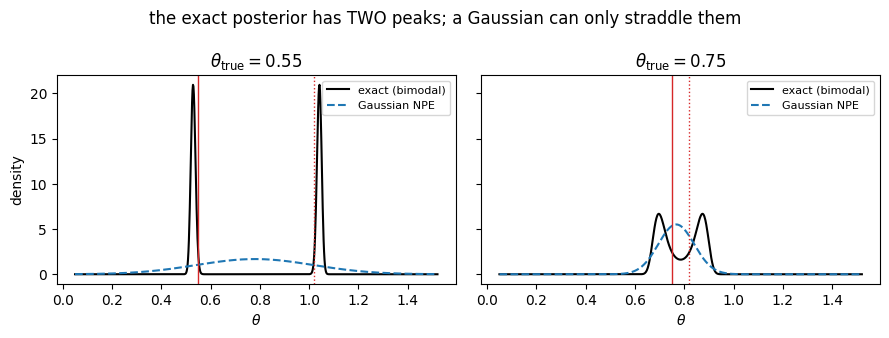

In [8]:
theta_grid_w = np.linspace(sim_wide.prior_low, sim_wide.prior_high, 800)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, theta_true in zip(axes, [0.55, 0.75]):
    x_obs = float(sim_wide.simulate_summary(np.array([theta_true]), n_balls=N_BALLS,
                                            rng=np.random.default_rng(int(1000 * theta_true)))[0])
    with torch.no_grad():
        mu, lv = model_w(torch.tensor([[x_obs]], dtype=torch.float32))
    mu = mu.item(); sg = float(torch.exp(0.5 * lv).item())
    q = (1 / (sg * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((theta_grid_w - mu) / sg) ** 2)
    _, p_true = sim_wide.true_posterior(x_obs, n_balls=N_BALLS, theta_grid=theta_grid_w)
    ax.plot(theta_grid_w, p_true, "k-", lw=1.5, label="exact (bimodal)")
    ax.plot(theta_grid_w, q, "C0--", lw=1.5, label="Gaussian NPE")
    ax.axvline(theta_true, color="C3", lw=1)
    ax.axvline(np.pi / 2 - theta_true, color="C3", lw=1, ls=":")
    ax.set_xlabel(r"$\theta$"); ax.set_title(fr"$\theta_{{\rm true}} = {theta_true}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("the exact posterior has TWO peaks; a Gaussian can only straddle them")
fig.tight_layout(); plt.show()

The exact posterior (black) has two peaks — the true angle and its reflection
about `45°`. The Gaussian head (blue) cannot represent two peaks. **This is not an optimisation failure.**
More epochs, more width, a smaller learning rate — none of it helps, because
the Gaussian *family* does not contain a bimodal density. As we argued in §2,
the loss drives `q_φ` to the closest reachable density, and for a Gaussian
family that closest thing is this useless straddle. We need a more expressive
`q_φ`.

---
## 4 — Expressive density estimators

Two ways to give `q_φ(θ|x)` the flexibility to be bimodal, both trained on the
*same* pairs with the *same* maximum-likelihood objective.

### 4a — A mixture-density head

The smallest possible upgrade: instead of one Gaussian, output a **mixture of
`K` Gaussians** — `K` means, `K` log-variances, and `K` mixing logits, all as
functions of `x`. The loss is again the negative log-likelihood, now of a
mixture, which stays a plain `logsumexp`. With `K = 2` this can obviously
represent our two peaks.

### ✏️ EXERCISE 4a — the mixture negative log-likelihood

`MixtureDensityHead` (below) already outputs `(mu, log_var, logit)`, each of
shape `(batch, K)`. Implement `mdn_nll(theta, mu, log_var, logit)`: the mean
over the batch of the negative log-likelihood of a `K`-component Gaussian
mixture. Per sample,

$$ -\log \sum_{k} w_k \,\mathcal{N}(\theta;\, \mu_k,\, \sigma_k^2),
\qquad w_k = \mathrm{softmax}(\text{logit})_k. $$

Work in log-space with `torch.logsumexp` so it stays numerically stable:
`log w_k = log_softmax(logit)`, and `log N(θ; μ_k, σ_k²) =
−½[(θ−μ_k)²/σ_k² + log σ_k² + log 2π]`.

In [9]:
class MixtureDensityHead(nn.Module):
    """Mixture-of-K-Gaussians posterior head: mu_k(x), log σ²_k(x), logit_k(x)."""

    def __init__(self, k=2, hidden=64):
        super().__init__()
        self.k = k
        self.trunk = nn.Sequential(
            nn.Linear(1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.head_mu = nn.Linear(hidden, k)
        self.head_logvar = nn.Linear(hidden, k)
        self.head_logit = nn.Linear(hidden, k)

    def forward(self, x):
        h = self.trunk(x)
        return self.head_mu(h), self.head_logvar(h), self.head_logit(h)


def mdn_nll(theta, mu, log_var, logit):
    log_w = torch.log_softmax(logit, dim=-1)
    log_comp = -0.5 * (((theta - mu) ** 2) / torch.exp(log_var)
                       + log_var + np.log(2 * np.pi))
    log_dens = torch.logsumexp(log_w + log_comp, dim=-1)
    return (-log_dens).mean()

In [10]:
def mdn_density(model, x_obs, grid):
    """Evaluate the trained mixture posterior on a theta grid (physical units)."""
    with torch.no_grad():
        mu, lv, logit = model(torch.tensor([[x_obs]], dtype=torch.float32))
    w = torch.softmax(logit, -1).numpy().ravel()
    mu = mu.numpy().ravel(); sg = np.exp(0.5 * lv.numpy().ravel())
    dens = np.zeros_like(grid)
    for wk, mk, sk in zip(w, mu, sg):
        dens += wk * (1 / (sk * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((grid - mk) / sk) ** 2)
    return dens


torch.manual_seed(SEED)
model = MixtureDensityHead(k=2)
opt = optim.Adam(model.parameters(), lr=1e-3)
n = x_wt.shape[0]
bar = trange(300, desc="train mixture head", leave=False)
for _ in bar:
    perm = torch.randperm(n)
    for i in range(0, n, 256):
        idx = perm[i:i + 256]
        opt.zero_grad()
        loss = mdn_nll(theta_wt[idx], *model(x_wt[idx]))
        loss.backward(); opt.step()
    bar.set_postfix(loss=f"{loss.item():.3f}")

train mixture head:   0%|          | 0/300 [00:00<?, ?it/s]

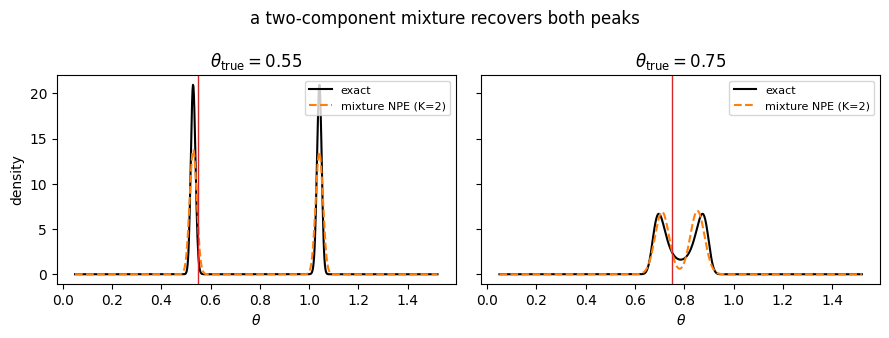

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, theta_true in zip(axes, [0.55, 0.75]):
    x_obs = float(sim_wide.simulate_summary(np.array([theta_true]), n_balls=N_BALLS,
                                            rng=np.random.default_rng(int(1000 * theta_true)))[0])
    q = mdn_density(model, x_obs, theta_grid_w)
    _, p_true = sim_wide.true_posterior(x_obs, n_balls=N_BALLS, theta_grid=theta_grid_w)
    ax.plot(theta_grid_w, p_true, "k-", lw=1.5, label="exact")
    ax.plot(theta_grid_w, q, "C1--", lw=1.5, label="mixture NPE (K=2)")
    ax.axvline(theta_true, color="C3", lw=1)
    ax.set_xlabel(r"$\theta$"); ax.set_title(fr"$\theta_{{\rm true}} = {theta_true}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("a two-component mixture recovers both peaks")
fig.tight_layout(); plt.show()

Both peaks — from the same pairs and the same NLL, just a more expressive head. A mixture is the cheap fix when you *know* the shape is a handful of blobs. But you rarely know `K` in advance, and in many dimensions a mixture is awkward. The general-purpose tool is a flow.

### 4b — Flow matching

A **normalising flow** learns to bend a simple distribution (a unit Gaussian)
into whatever the posterior actually is, curvature, multimodality and all. We
train it with **flow matching**: a plain regression loss on a velocity field,
no density evaluation and no Jacobian at train time.

**Training.** Draw a data point `θ₁`, a noise point `θ₀ ~ N(0, I)` and a time
`t ~ U(0,1)`; sit on the straight line between them and regress the network's
velocity onto the direction `θ₁ − θ₀`:

$$ \mathcal{L}(\phi) = \mathbb{E}_{t,\theta_0,(\theta_1,c)}
\big\| v_\phi\big((1-t)\theta_0 + t\theta_1,\ t \mid c\big) - (\theta_1 - \theta_0)\big\|^2. $$

**Sampling.** Draw noise and Euler-integrate `dθ/dt = v_φ(θ, t | c)` from
`t = 0` to `t = 1`. Here the condition `c` is the observation `x`.

In [12]:
def mlp(d_in, d_out, hidden, layers):
    """Generic MLP helper: R^d_in -> R^d_out through `layers` hidden blocks."""
    mods, d = [], d_in
    for _ in range(layers):
        mods += [nn.Linear(d, hidden), nn.ReLU()]
        d = hidden
    return nn.Sequential(*mods, nn.Linear(d, d_out))


def fm_loss(net, th1, cond):
    """Equation 1: the flow-matching objective."""
    th0 = torch.randn_like(th1)                     # theta_0 ~ N(0, I): noise point
    t = torch.rand(len(th1), 1, device=th1.device)   # t ~ U(0, 1), one per example
    tht = (1 - t) * th0 + t * th1                   # theta_t on the straight line
    v = net(tht, t, cond)                           # velocity the network predicts
    return ((v - (th1 - th0)) ** 2).mean()          # regress onto theta_1 - theta_0


class VelocityNet(nn.Module):
    """Velocity field v(theta, t | cond): an MLP with a Fourier embedding of t."""

    def __init__(self, d_theta, d_cond, hidden=128, layers=3):
        super().__init__()
        self.freqs = torch.tensor([1., 2., 4., 8.])           # time-embedding freqs
        self.net = mlp(d_theta + 9 + d_cond, d_theta, hidden, layers)

    def forward(self, th, t, cond):
        ft = 2 * np.pi * t * self.freqs.to(t.device)          # (n, 4) scaled times
        temb = torch.cat([t, ft.sin(), ft.cos()], 1)          # (n, 9): t and 4 sin/cos
        return self.net(torch.cat([th, temb, cond], 1))       # -> (n, d_theta)


@torch.no_grad()
def fm_sample(net, cond, d_theta, steps=64):
    """Equation 2: Euler-integrate dtheta/dt = v from t=0 (noise) to t=1."""
    n = len(cond)
    th = torch.randn(n, d_theta, device=cond.device)          # theta(0) ~ N(0, I)
    for i in range(steps):
        t = torch.full((n, 1), (i + 0.5) / steps, device=cond.device)  # midpoint
        th = th + net(th, t, cond) / steps          # Euler step: theta += v * dt
    return th


def train_fm(net, th1, cond, steps=3000, batch=512, lr=1e-3, log=True):
    """Minimize fm_loss by Adam -- the same loop as a plain regression fit.

    The flow-matching target (theta_1 - theta_0) is stochastic by construction:
    theta_0 and t are redrawn every call, so a single-minibatch loss is too
    noisy to read and never reaches zero. We therefore report an AVERAGED loss
    on the full data (several fresh draws of the noise, averaged), which shows
    the real trend -- a quick drop early, then a plateau at a nonzero floor.
    """
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    @torch.no_grad()
    def avg_loss(reps=20):
        # average out the theta_0 / t noise so the number is stable
        return float(np.mean([fm_loss(net, th1, cond).item() for _ in range(reps)]))

    for step in range(steps):
        i = torch.randint(0, len(th1), (batch,), device=th1.device)  # minibatch
        loss = fm_loss(net, th1[i], cond[i])                         # forward
        opt.zero_grad(); loss.backward(); opt.step()                 # zero, backward, step
        if log and (step + 1) % 100 == 0:
            print(f'  step {step + 1}/{steps}  loss {avg_loss():.3f}')
    return net

### ✏️ EXERCISE 4b — train the flow and read out one posterior

The pairs `(θ, x)` are already made (`theta_wt`, `x_wt`, the wide prior). Two
things to do, both one-liners over the helpers above:

1. **Train.** z-score both `θ` and `x` (flows want `O(1)` inputs — the buffers
   `t_mu/t_sd/x_mu/x_sd` are provided), build a `VelocityNet(d_theta=1,
   d_cond=1)`, and call `train_fm` on the z-scored tensors.
2. **Sample.** For the observation `x_obs` below, draw 4000 posterior samples
   with `fm_sample`, un-z-score them, and we histogram them against the exact
   posterior.

In [13]:
# z-scoring constants (kept so we can map the network's O(1) world back to physics)
t_mu, t_sd = theta_wt.mean(0), theta_wt.std(0)
x_mu, x_sd = x_wt.mean(0), x_wt.std(0)
theta_zn = (theta_wt - t_mu) / t_sd
x_zn = (x_wt - x_mu) / x_sd

x_obs = float(sim_wide.simulate_summary(np.array([theta_true]), n_balls=N_BALLS,
                                        rng=np.random.default_rng(550))[0])

flow = VelocityNet(1, 1)
train_fm(flow, theta_zn, x_zn, steps=3000)
cond = ((torch.tensor([[x_obs]], dtype=torch.float32) - x_mu) / x_sd).expand(4000, 1)
post = (fm_sample(flow, cond, 1) * t_sd + t_mu).numpy().ravel()

  step 100/3000  loss 1.117
  step 200/3000  loss 1.029
  step 300/3000  loss 0.987
  step 400/3000  loss 0.986
  step 500/3000  loss 0.962
  step 600/3000  loss 0.958
  step 700/3000  loss 0.964
  step 800/3000  loss 0.961
  step 900/3000  loss 0.968
  step 1000/3000  loss 0.933
  step 1100/3000  loss 0.946
  step 1200/3000  loss 0.939
  step 1300/3000  loss 0.937
  step 1400/3000  loss 0.938
  step 1500/3000  loss 0.932
  step 1600/3000  loss 0.943
  step 1700/3000  loss 0.939
  step 1800/3000  loss 0.977
  step 1900/3000  loss 0.954
  step 2000/3000  loss 0.953
  step 2100/3000  loss 0.940
  step 2200/3000  loss 0.949
  step 2300/3000  loss 0.947
  step 2400/3000  loss 0.942
  step 2500/3000  loss 0.941
  step 2600/3000  loss 0.932
  step 2700/3000  loss 0.942
  step 2800/3000  loss 0.938
  step 2900/3000  loss 0.951
  step 3000/3000  loss 0.928


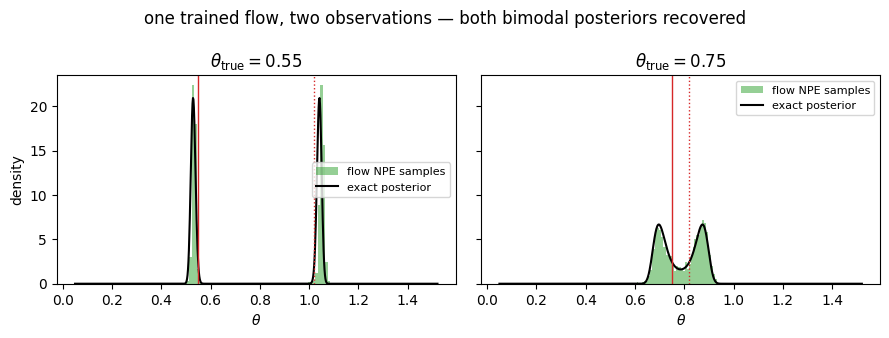

In [14]:
theta_trues = [0.55, 0.75]
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), sharey=True)
for ax, theta_true in zip(axes, theta_trues):
    x_obs = float(sim_wide.simulate_summary(np.array([theta_true]), n_balls=N_BALLS,
                                            rng=np.random.default_rng(int(1000 * theta_true)))[0])
    # amortised: the SAME trained flow, just condition on this x_obs — no retraining
    cond = ((torch.tensor([[x_obs]], dtype=torch.float32) - x_mu) / x_sd).expand(4000, 1)
    post = (fm_sample(flow, cond, 1) * t_sd + t_mu).numpy().ravel()

    _, p_true = sim_wide.true_posterior(x_obs, n_balls=N_BALLS, theta_grid=theta_grid_w)
    ax.hist(post, bins=60, density=True, color="C2", alpha=0.5, label="flow NPE samples")
    ax.plot(theta_grid_w, p_true, "k-", lw=1.5, label="exact posterior")
    ax.axvline(theta_true, color="C3", lw=1)                       # true angle
    ax.axvline(np.pi / 2 - theta_true, color="C3", lw=1, ls=":")   # its reflection
    ax.set_xlabel(r"$\theta$"); ax.set_title(fr"$\theta_{{\rm true}} = {theta_true}$")
    ax.legend(fontsize=8)
axes[0].set_ylabel("density")
fig.suptitle("one trained flow, two observations — both bimodal posteriors recovered")
fig.tight_layout(); plt.show()

The flow fills both peaks with the right relative weight — no mixture count to
choose, no shape assumed. Same simulator, same maximum-likelihood objective,
strictly more expressive `q_φ`. From here on, "the flow" means this object.

---
## 5 — Calibration: is the posterior *honest*?

A posterior can have the right shape and still be **miscalibrated** — too
narrow (overconfident) or too wide (underconfident). Shape-matching to a
reference is a luxury we only have on toys; on a real problem we cannot see
the truth. What we *can* always do is a self-consistency check that needs no
reference: **simulation-based calibration (SBC)**.

**The idea.** If `q_φ(θ|x)` were the exact posterior, then for a fresh pair
`θ* ~ p(θ)`, `x* ~ p(x|θ*)`, the **rank** of `θ*` among posterior samples
drawn from `q_φ(·|x*)` is uniformly distributed. Repeat over many pairs and
histogram the ranks:

- **flat** → calibrated;
- **∩-shaped** (ranks pile in the middle) → posterior too **wide**
  (underconfident);
- **∪-shaped** (ranks pile at the ends) → posterior too **narrow**
  (overconfident) — the truth keeps landing in the tails.

The equivalent statement in coverage terms: the fraction of pairs whose true
`θ*` falls inside the central `α` credible interval should equal `α`. Plotting
empirical coverage vs nominal `α` gives the **expected-coverage curve**;
the diagonal is perfect, below-diagonal is overconfident.

We run both diagnostics on the **Gaussian head** and the **flow** from the
wide-prior (bimodal) problem, side by side. The Gaussian head we already know
is wrong in *shape*; SBC is how you would have caught it *without* the exact
posterior.

In [15]:
# One shared test set of fresh (theta*, x*) pairs from the wide prior.
rng = np.random.default_rng(123)
N_SBC = 500
theta_star = sim_wide.sample_prior(N_SBC, rng=rng)
x_star = sim_wide.simulate_summary(theta_star, n_balls=N_BALLS, rng=rng)
x_star_t = torch.tensor(x_star, dtype=torch.float32).unsqueeze(1)
L = 200   # posterior draws per pair for ranking


def gauss_posterior_samples(model, x_obs_t, n):
    """Draw n samples from the Gaussian head's posterior for each observation."""
    with torch.no_grad():
        mu, lv = model(x_obs_t)                    # (N, 1) each
    sd = torch.exp(0.5 * lv)
    eps = torch.randn(x_obs_t.shape[0], n)
    return (mu + sd * eps).numpy()                 # (N, n)


def flow_posterior_samples(flow, x_obs_t, n):
    """Draw n samples from the flow's posterior for each observation (z-scored in/out)."""
    cond = ((x_obs_t - x_mu) / x_sd)               # (N, 1)
    cond = cond.repeat_interleave(n, dim=0)        # (N*n, 1)
    s = (fm_sample(flow, cond, 1) * t_sd + t_mu).numpy().ravel()
    return s.reshape(x_obs_t.shape[0], n)


samples_gauss = gauss_posterior_samples(model_w, x_star_t, L)
samples_flow = flow_posterior_samples(flow, x_star_t, L)

### ✏️ EXERCISE 5 — ranks, coverage, and a verdict

You are given, for each model, an array `samples` of shape `(N_SBC, L)`: `L`
posterior draws for each of the `N_SBC` test observations, plus the true
`theta_star` (shape `(N_SBC,)`). Implement two functions, then **read the two
diagnostics and state which model is overconfident and how you can tell.**

1. `sbc_ranks(samples, truth)` → the rank of each truth among its `L` draws,
   i.e. `(samples < truth[:, None]).sum(axis=1)`, an integer array of length
   `N_SBC` (values `0..L`).
2. `coverage_curve(samples, truth, alphas)` → for each nominal level `α`, the
   fraction of pairs whose truth lies inside the central-`α` credible interval
   (between the `(1−α)/2` and `(1+α)/2` empirical quantiles of its draws).

Then write your one-sentence verdict in `VERDICT` at the bottom.

In [16]:
def sbc_ranks(samples, truth):
    return (samples < truth[:, None]).sum(axis=1)


def coverage_curve(samples, truth, alphas):
    cov = []
    for a in alphas:
        lo = np.quantile(samples, (1 - a) / 2, axis=1)
        hi = np.quantile(samples, (1 + a) / 2, axis=1)
        cov.append(np.mean((truth >= lo) & (truth <= hi)))
    return np.array(cov)

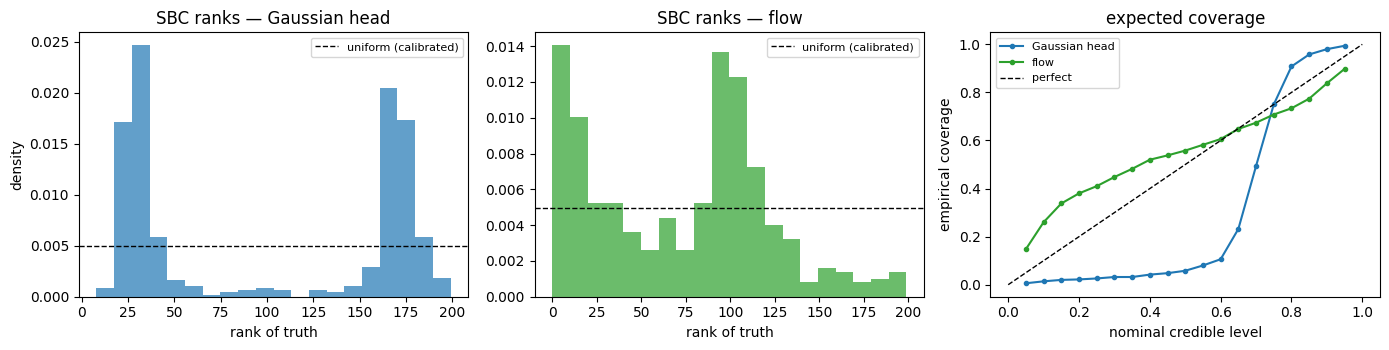

The Gaussian head is badly OVERCONFIDENT. The decisive, reference-free tell is the coverage curve: it sits well BELOW the diagonal at the levels that matter — its nominal 50% credible interval contains the truth only about a sixth of the time — because a single mode wedged between the two real peaks is confidently wrong. Its rank histogram is correspondingly far from flat. The flow's coverage tracks the diagonal (if anything a touch conservative) and its ranks are close to uniform, so it is well calibrated. Rule of thumb: coverage below the diagonal = overconfident, above = underconfident.


In [17]:
alphas = np.linspace(0.05, 0.95, 19)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))

for name, samp, c in [("Gaussian head", samples_gauss, "C0"), ("flow", samples_flow, "C2")]:
    ranks = sbc_ranks(samp, theta_star)
    ax = axes[0] if name == "Gaussian head" else axes[1]
    ax.hist(ranks, bins=20, density=True, color=c, alpha=0.7)
    ax.axhline(1.0 / (L + 1), color="k", ls="--", lw=1, label="uniform (calibrated)")
    ax.set_xlabel("rank of truth"); ax.set_title(f"SBC ranks — {name}")
    ax.legend(fontsize=8)
    cov = coverage_curve(samp, theta_star, alphas)
    axes[2].plot(alphas, cov, "o-", ms=3, color=c, label=name)

axes[0].set_ylabel("density")
axes[2].plot([0, 1], [0, 1], "k--", lw=1, label="perfect")
axes[2].set_xlabel("nominal credible level"); axes[2].set_ylabel("empirical coverage")
axes[2].set_title("expected coverage"); axes[2].legend(fontsize=8)
fig.tight_layout(); plt.show()

VERDICT = (
    "The Gaussian head is badly OVERCONFIDENT. The decisive, reference-free tell "
    "is the coverage curve: it sits well BELOW the diagonal at the levels that "
    "matter — its nominal 50% credible interval contains the truth only about a "
    "sixth of the time — because a single mode wedged between the two real peaks "
    "is confidently wrong. Its rank histogram is correspondingly far from flat. "
    "The flow's coverage tracks the diagonal (if anything a touch conservative) "
    "and its ranks are close to uniform, so it is well calibrated. Rule of thumb: "
    "coverage below the diagonal = overconfident, above = underconfident."
)
print(VERDICT)

**Why this matters.** The rank histogram and coverage curve used *no* exact
posterior — only the simulator and the trained network. That is the whole
point: on a real problem this is the only kind of check you get, and it is
enough to catch an overconfident model before you trust its error bars. A flow
that passes SBC is not guaranteed correct, but a model that fails it is
definitely not to be trusted.

---
## 6 — Amortised vs sequential, at a fixed budget

Everything so far was **amortised**: train on the whole prior, reuse for any
`x`. That is wasteful if you only care about **one** observation — most of the
simulations land nowhere near its posterior. **Sequential** inference spends
the same budget in rounds ("rungs"), each simulating only where the current
estimate points, so the training data concentrates on the answer. This is the
idea behind the dynamic-SBI loop notebook 2 is built around; here it is in
miniature on the ball-throw.

We fix a total simulation budget and compare, on one observation:

- **Amortised** — spend the whole budget once, sampling `θ` from the full
  (wide) prior;
- **Sequential** — split the budget into two rungs. Rung 1 uses the wide
  prior; we then read off a credible region and, for rung 2, simulate only
  from that truncated prior, retraining the flow on the concentrated pairs.

For a clean comparison we pick an observation near the top of the range, where
the two angle-modes merge into a single peak (so "posterior width" is a
meaningful scalar), and plot width vs budget.

In [18]:
def train_flow_on(theta_np, x_np, steps=1500):
    """Fit a fresh flow to given (theta, x) pairs; return (flow, z-score consts)."""
    th = torch.tensor(theta_np, dtype=torch.float32).unsqueeze(1)
    xx = torch.tensor(x_np, dtype=torch.float32).unsqueeze(1)
    tm, ts = th.mean(0), th.std(0); xm, xs = xx.mean(0), xx.std(0)
    net = VelocityNet(1, 1)
    train_fm(net, (th - tm) / ts, (xx - xm) / xs, steps=steps, log=False)
    return net, (tm, ts, xm, xs)


def flow_post(net, consts, x_obs, n=4000):
    tm, ts, xm, xs = consts
    cond = ((torch.tensor([[x_obs]], dtype=torch.float32) - xm) / xs).expand(n, 1)
    return (fm_sample(net, cond, 1) * ts + tm).numpy().ravel()


# One target observation, near the top of the range (single-peak posterior).
theta_tgt = 0.78
x_obs6 = float(sim_wide.simulate_summary(np.array([theta_tgt]), n_balls=N_BALLS,
                                         rng=np.random.default_rng(780))[0])
BUDGET = 8000

### ✏️ EXERCISE 6 — build the two-rung sequential proposal

The amortised baseline is given. For the sequential run, fill in the **rung-2
truncated prior**: from the rung-1 posterior samples `post1`, take a central
credible interval (say 2.5–97.5%), clip it to the prior box, and draw the
rung-2 parameters uniformly from that interval. Then simulate and retrain.
The point to observe: at the *same total budget*, the sequential posterior is
narrower, because rung 2 spent its simulations where the answer actually is.

In [19]:
rng = np.random.default_rng(6)

# --- Amortised: whole budget from the wide prior ---
theta_a = sim_wide.sample_prior(BUDGET, rng=rng)
x_a = sim_wide.simulate_summary(theta_a, n_balls=N_BALLS, rng=rng)
flow_a, consts_a = train_flow_on(theta_a, x_a)
post_a = flow_post(flow_a, consts_a, x_obs6)

# --- Sequential rung 1: half the budget from the wide prior ---
half = BUDGET // 2
theta_1 = sim_wide.sample_prior(half, rng=rng)
x_1 = sim_wide.simulate_summary(theta_1, n_balls=N_BALLS, rng=rng)
flow_1, consts_1 = train_flow_on(theta_1, x_1)
post1 = flow_post(flow_1, consts_1, x_obs6)

# --- Sequential rung 2: half the budget from a TRUNCATED prior around post1 ---
lo = max(sim_wide.prior_low, np.percentile(post1, 2.5))
hi = min(sim_wide.prior_high, np.percentile(post1, 97.5))
theta_2 = rng.uniform(lo, hi, half)
x_2 = sim_wide.simulate_summary(theta_2, n_balls=N_BALLS, rng=rng)
flow_2, consts_2 = train_flow_on(theta_2, x_2)
post_s = flow_post(flow_2, consts_2, x_obs6)

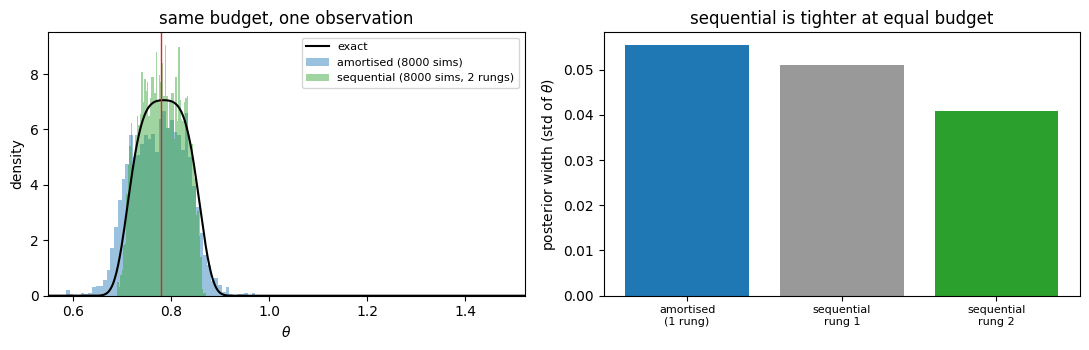

In [20]:
_, p_true6 = sim_wide.true_posterior(x_obs6, n_balls=N_BALLS, theta_grid=theta_grid_w)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 3.6))
axL.plot(theta_grid_w, p_true6, "k-", lw=1.5, label="exact")
axL.hist(post_a, bins=60, density=True, color="C0", alpha=0.45,
         label=f"amortised ({BUDGET} sims)")
axL.hist(post_s, bins=60, density=True, color="C2", alpha=0.45,
         label=f"sequential ({BUDGET} sims, 2 rungs)")
axL.axvline(theta_tgt, color="C3", lw=1)
axL.set_xlim(0.55, sim_wide.prior_high)
axL.set_xlabel(r"$\theta$"); axL.set_ylabel("density"); axL.legend(fontsize=8)
axL.set_title("same budget, one observation")

widths = {"amortised\n(1 rung)": post_a.std(),
          "sequential\nrung 1": post1.std(),
          "sequential\nrung 2": post_s.std()}
axR.bar(range(len(widths)), list(widths.values()),
        color=["C0", "0.6", "C2"])
axR.set_xticks(range(len(widths))); axR.set_xticklabels(list(widths.keys()), fontsize=8)
axR.set_ylabel(r"posterior width (std of $\theta$)")
axR.set_title("sequential is tighter at equal budget")
fig.tight_layout(); plt.show()

At the **same** total simulation count, the sequential posterior is tighter:
rung 2 spent every simulation inside the credible region rung 1 found, so the
flow saw far more relevant training data there. That is the win — and the
catch. Sequential inference is **not amortised** (this flow only knows about
`x_obs6`; the amortised one works for any `x`), and it needs careful
bookkeeping: which proposal each rung drew from, how to reweight so you target
the true posterior and not `Lᵞ·prior`, how to avoid zooming onto the wrong
mode. Doing that bookkeeping *by hand* across many rounds, nodes and
parameters is exactly the drudgery a framework should own.

**That framework is `falcon`, and it is where notebook 2 goes** — the same
ideas (a flow posterior, learned compression, a sequential zoom) on a real
gravitational-wave chirp, driven entirely from YAML.

### Where this leaves you

- An amortised NPE is a network trained on simulator pairs with a
  maximum-likelihood loss; §2 showed *why* that loss returns the posterior.
- A Gaussian head fails whenever the true posterior isn't Gaussian; mixtures
  and flows fix the *shape*.
- SBC / expected coverage tells you whether the *width* is honest, using only
  the simulator — no exact posterior required.
- Sequential inference buys precision per simulation by moving the training
  distribution, at the cost of amortisation and a lot of bookkeeping.